In [3]:
import os
import random
from typing import List, Tuple, Dict, Any, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import optuna
from optuna.samplers import TPESampler
from optuna.storages import RDBStorage

from utils import plot_training_curves, plot_roc_curve, plot_predictions_distribution

# General Configuration

In [ ]:
# Limit CPU threads
NUM_CPU = 4
os.environ["OMP_NUM_THREADS"] = str(NUM_CPU)
os.environ["MKL_NUM_THREADS"] = str(NUM_CPU)
torch.set_num_threads(NUM_CPU)
try:
    torch.set_num_interop_threads(NUM_CPU)
except Exception:
    pass
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
# Paths and configuration
BASE_DIR = os.getcwd()
TRAINING_PICKLE = os.path.abspath(f"{BASE_DIR}/from_albert/training_file_kaon_pion.pkl")
OUTPUT_DIR = os.path.abspath(f"{BASE_DIR}/outputs")
OUTPUT_PICKLE = f"{OUTPUT_DIR}/predictions.pkl"
CHECKPOINT_PATH = f"{OUTPUT_DIR}/best_model.pt"
OPTUNA_DB_URL = f"sqlite:///{OUTPUT_DIR}/optuna_studies.db"
STUDY_NAME = "mlp_hyperparameter_optimization"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Configuration flags
USE_STANDARD_SCALER = True

# Number of trials to run for hyperparameter optimization
OPTUNA_N_TRIALS = 5

# Fixed hyperparameters
TEST_SIZE = 0.3
RANDOM_STATE = 42
EPOCHS = 1000
VALIDATE_EVERY = 10
FEATURE_COLS = [
    "Positive_Energy_FCAL",
    "Positive_E1E9_FCAL",
    "Positive_E9E25_FCAL",
    "Positive_SumU_FCAL",
    "Positive_SumV_FCAL",
    "Positive_TrackFCAL_DOCA",
    # ---
    "Negative_Energy_FCAL",
    "Negative_E1E9_FCAL",
    "Negative_E9E25_FCAL",
    "Negative_SumU_FCAL",
    "Negative_SumV_FCAL",
    "Negative_TrackFCAL_DOCA",
]

# Code structure

There are several functions (and classes) that are used in this tutorial. This diagram generally shows how they connect together. *Red* boxes show functions used in hyperparameter optimization. 

<img src="images/code-diagram.png" width='1000'>

# Core Elements in Supervised Learning

NOTE: Code is written to be succint for hyperparameter optimization

1. **Data:**
    - For supervised learning, this is the input and output pairs we wish to learn a mapping between
    - For this problem, we are mapping from some detector level variables, i.e. energy and shower shape variables, to some particle id, i.e. pion or kaon.
2. **Model:**
    - Parameterized mapping from inputs to outputs whose parameters can be learned
    - Multi-Layer Perceptron (MLP), basic/standard neural network is used in this tutorial
3. **Loss Function / Metrics:**
    - Quantifies the error between model predictions and data
    - Not all metrics are appropriate for all problems
      - Standard example is in disease detection where false negatives are much more costly than false positives
4. **Optimization:**
    - Learning algorithm that trains the model, i.e. backpropagation for neural networks provides gradients
    - Gradients are used by an optimizer like Adam to effectively navigate the parameter space.

## More formallly
1. We are learning $P(y|x, \theta)$ where
   - $x$ is the input
   - $y$ is the output (class label)
   - $\theta$ is the set of parameters of the model (neural network parameters).
2. We maximize the likelihood of the data (which is equivalent to minimizing the binary cross entropy, the loss function we use)
   - NOTE: to mirror the TMVA tutorial, we instead minimize the MSE (Brier score)
3. We optimize parameters using:
   - mini-batch gradient descent and Adam optimizer:
    - <img src="images/mini-batch-gradient-descent.png" width='1000'>
  - Optuna, as a black-box meta-optimization framework, will be used to optimize the hyperparameters in the (model, training) pipeline

# Data

PyTorch uses `DataLoader` object to load data arrays / tensors. These tensors maintain a few key attributes:
- `dtype` (datatype of the tensor, i.e. float32)
- `shape` (size of the tensor, i.e. (100, 10) is 2D with 100 rows and 10 columns)
- `device` (CPU, GPU, etc.)
- `grad` (stored gradient that is populated during `loss.backward()` call in training loop, see later sections)

Some important things to consider:
- **Cross validation** - split the data into subsets, train on one, validate on another.
    - An optimized model should perform well on trained data, using a held out validation dataset will give a handle on the **generalization** capabilities of the model.
    - We can perform an additional split into train/validation/test sets where the validation can be used to select the best hyperparameters
    - Remember, the final model performance should be evaluated on a truly held out test dataset
- **Standardization** - scale the data such that all features are on the same scale
  - important for gradient descent and maintaining equal weighting for metrics like mean squared error
  - typically scaling to be standard normal is done, can be done using `sklearn.preprocessing.StandardScaler`

In [ ]:
# Load and prepare data
df = pd.read_pickle(TRAINING_PICKLE)
df["label"] = df["pi_k"].map({1: 1.0, 0: -1.0})  # tanh output range [-1, 1]

# Handle missing DOCA values
# DOCA values are positive O(1), StandardScaler might be too dramatic with 999 special(sentinel) value
df.loc[df['Positive_TrackFCAL_DOCA'] == 999, 'Positive_TrackFCAL_DOCA'] = -1
df.loc[df['Negative_TrackFCAL_DOCA'] == 999, 'Negative_TrackFCAL_DOCA'] = -1

# GPU performance depends on data type, lots of FLOPS with float32
X = df[FEATURE_COLS].to_numpy(dtype=np.float32)
y = df["label"].to_numpy(dtype=np.float32)

# Split data: train/val/test for optimization
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True
)

# Apply scaling if requested
scaler = None
if USE_STANDARD_SCALER:
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)
    X = scaler.transform(X)

## Define Model

In [6]:
class MLP(nn.Module):
    def __init__(self, num_inputs: int, hidden_sizes: List[int]):
        super().__init__()
        self.layers = nn.ModuleList()
        prev_size = num_inputs
        for hidden_size in hidden_sizes:
            self.layers.append(nn.Linear(prev_size, hidden_size))
            prev_size = hidden_size
        self.output_layer = nn.Linear(prev_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.layers:
            x = torch.tanh(layer(x))
        x = torch.tanh(self.output_layer(x))
        return x

Helper function that helps create the Multi-Layer Perceptron (MLP) model dynamically for hyperparameter optimization

We vary the following:
- number of hidden layers
- number of neurons per hidden layer

In [7]:
def create_model_architecture(params: Dict[str, Any], num_inputs: int) -> MLP:
    """Create MLP model based on suggested hyperparameters."""
    hidden_sizes = []
    current_size = num_inputs

    for _ in range(params['hidden_layers']):
        layer_size = int(current_size * params['hidden_size_multiplier'])
        hidden_sizes.append(layer_size)
        current_size = layer_size  # For next layer
    
    return MLP(
        num_inputs=num_inputs,
        hidden_sizes=hidden_sizes
    )

# Training Loop

This is the main training loop that will be executed for each hyperparameter optimization trial and for the final best model training.

For this tutorial, we vary the hyperparameters of the optimizer, Adam:
- learning rate
- weight decay

The loss function we use here is the mean squared error, MSE, loss function. 

Here is an example training loop in PyTorch which tracks a few metrics (loss, accuracy, and AUC). Some things to note:
- PyTorch requires model and data to be on the same device, use `.to(device)` to move them
- Loop over batches of (input, output) pairs provided by PyTorch DataLoaders, see later sections
  - At each iteration we:
    1. zero the gradients, `optimizer.zero_grad()`. Gradients are accumulated between iterations by default
    2. compute the loss, `loss = criterion(preds, yb)`
    3. backpropagate, `loss.backward()`, get gradients with respect to the loss
    4. update the model parameters, `optimizer.step()`, use gradients to update the model parameters
    5. track various metrics
- Do the same for validation dataset but now we do not need gradients


In [ ]:
def train_model(model: MLP, train_loader: DataLoader, val_loader: DataLoader, 
                device: torch.device, epochs: int = EPOCHS, 
                validate_every: int = VALIDATE_EVERY, patience: int = 50,
                return_history: bool = False) -> Tuple[float, float, Optional[Dict]]:
    """Train a model and return validation metrics."""
    optimizer = torch.optim.Adam(model.parameters())
    criterion = nn.MSELoss()
    
    # Track training progress
    train_losses, val_losses = [], []
    val_aucs, val_accs = [], []
    best_val_auc, best_val_acc = -np.inf, 0.0
    patience_counter = 0
    
    for epoch in range(1, epochs + 1):
        model.train() # model can act differently in training and evaluation time (i.e. dropout)
        running_loss = 0.0
        num_samples = 0
        
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * xb.size(0)
            num_samples += xb.size(0)
        
        avg_train_loss = running_loss / max(1, num_samples)
        train_losses.append(avg_train_loss)
        val_losses.append(np.nan)
        val_aucs.append(np.nan)
        val_accs.append(np.nan)
        
        # Validation
        if epoch % validate_every == 0 or epoch == epochs:
            model.eval()
            with torch.no_grad():
                y_true_list, y_pred_list = [], []
                val_loss_sum, val_n = 0.0, 0
                
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    preds = model(xb)
                    loss = criterion(preds, yb)
                    val_loss_sum += loss.item() * xb.size(0)
                    val_n += xb.size(0)
                    y_true_list.append(yb.squeeze(1).cpu().numpy())
                    y_pred_list.append(preds.squeeze(1).cpu().numpy())
                
                y_true = np.concatenate(y_true_list, axis=0)
                y_pred = np.concatenate(y_pred_list, axis=0)
                
                # Convert tanh output [-1,1] to probabilities [0,1]
                y_prob = (y_pred + 1.0) / 2.0
                y_prob_true = ((y_true + 1.0) / 2.0).astype(int)
                
                # Calculate metrics
                try:
                    val_auc = roc_auc_score(y_prob_true, y_prob)
                except ValueError:
                    val_auc = 0.5
                val_acc = accuracy_score(y_prob_true, (y_pred >= 0.0).astype(int))
                val_loss = val_loss_sum / max(1, val_n)
                
                val_losses[-1] = val_loss
                val_aucs[-1] = val_auc
                val_accs[-1] = val_acc
                
                # Track best metrics and early stopping
                if val_auc > best_val_auc:
                    best_val_auc, best_val_acc = val_auc, val_acc
                    patience_counter = 0
                else:
                    patience_counter += 1
                    if patience_counter >= patience:
                        break
    
    if return_history:
        history = {
            'train_losses': train_losses,
            'val_losses': val_losses,
            'val_aucs': val_aucs,
            'val_accs': val_accs
        }
        return best_val_auc, best_val_acc, history
    else:
        return best_val_auc, best_val_acc

# Hyperparameter Optimization

Optuna, is a python package for hyperparameter optimization. It provides access to several optimization algorithms and can perform multi-objective optimization, MOO, also. In this tutorial, we use the Tree-structured Parzen Estimator, TPE, algorithm and optimize the multi-objective, (AUC, accuracy), against 5 hyperparameters:
- Optimizer hyperparameters:
    - learning rate
    - weight decay
- Training loop hyperparameters:
    - batch size
- Model hyperparameters:
    - number of hidden layers
    - number of neurons per hidden layer

NOTE: optimizing (AUC, accuracy) is a bit silly since they are highly correlated

Optuna tracks their "suggested" values for each trial and can suggest values with different data types and ranges.

In [ ]:
def suggest_hyperparameters(trial: optuna.Trial, num_inputs: int) -> Dict[str, Any]:
    """Suggest hyperparameters for a trial using Optuna's suggest methods."""
    return {
        'batch_size': trial.suggest_int("batch_size", 256, 2048, step=256),
        'learning_rate': trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True),
        'weight_decay': trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True),
        'hidden_layers': trial.suggest_int('hidden_layers', 1, 3),
        'hidden_size_multiplier': trial.suggest_float('hidden_size_multiplier', 0.5, 3.0),
    }

We can wrap the `train_model` function with additional functionality to dynamically create the pipeline based on Optuna's suggested hyperparameters

In [ ]:
def train_single_trial(trial: optuna.Trial, X_train: np.ndarray, y_train: np.ndarray, 
                      X_val: np.ndarray, y_val: np.ndarray, device: torch.device) -> Tuple[float, float]:
    """Train a single model trial and return validation metrics."""
    params = suggest_hyperparameters(trial, X_train.shape[1])
    
    # Track model architecture, can view them in the dashboard later
    trial.set_user_attr("model_architecture", f"hidden_layers={params['hidden_layers']}, multiplier={params['hidden_size_multiplier']:.2f}")
    
    # Create model and track total parameters
    model = create_model_architecture(params, X_train.shape[1]).to(device)
    total_params = sum(p.numel() for p in model.parameters()) # numel = number of elements
    trial.set_user_attr("total_parameters", total_params)
    
    # Create data loaders
    train_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().view(-1, 1)),
        batch_size=params['batch_size'],
        shuffle=True,
    )
    val_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).float().view(-1, 1)),
        batch_size=params['batch_size'],
        shuffle=False,
    )
    
    # Train model
    best_val_auc, best_val_acc = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        epochs=EPOCHS,
        validate_every=VALIDATE_EVERY,
        patience=50
    )
    
    # Store results
    trial.set_user_attr("best_val_auc", best_val_auc)
    trial.set_user_attr("best_val_acc", best_val_acc)
    return best_val_auc, best_val_acc

An Optuna `study` needs to be created (or loaded) which maintains the trials and their results. 

The `train_single_trial` function, defined above, will be run for each trial returning (AUC, accuracy) values which are optimized in a specific direction, (maximize, maximize), as we would like high AUC and accuracy
- Again, this is silly since AUC and accuracy are highly correlated

In [ ]:
def optimize_hyperparameters(n_trials: int = 100) -> optuna.Study:
    """Run hyperparameter optimization using Optuna."""
    set_seed(RANDOM_STATE) # reset the seed
    
    # Create / Load a study and run / continue optimization
    storage = RDBStorage(OPTUNA_DB_URL) # Database to store results in
    try:
        study = optuna.load_study(
            study_name=STUDY_NAME,
            storage=storage,
            sampler=TPESampler(seed=RANDOM_STATE)
        )
        print(f"Loaded existing study: {STUDY_NAME} ({len(study.trials)} trials)")
    except KeyError:
        study = optuna.create_study(
            study_name=STUDY_NAME,
            storage=storage,
            directions=['maximize', 'maximize'],  # Multi-objective: AUC and accuracy
            sampler=TPESampler(seed=RANDOM_STATE)
        )
        print(f"Created new study: {STUDY_NAME}")

    # The objective to optimize
    def objective(trial):
        try:
            return train_single_trial(trial, X_train, y_train, X_val, y_val, device)
        except Exception as e:
            print(f"Trial failed: {e}")
            return 0.0, 0.0
    
    print(f"Starting optimization with {n_trials} trials...")
    study.optimize(objective, n_trials=n_trials)
    return study

The following bit of code loads the best hyperparameters and trains the final model. This code has overlap with `train_single_trial` but a few things to note:
- We initially split the data into train/validation/test sets
  - For hyperparameter optimization we used the metrics on the validation dataset to determine the best hyperparameters
  - For the final model, we can train using the train/validation datasets and evaluate on the truly held out test dataset
- We make several plots, checkpoint (save) the PyTorch model, and store the predictions

In [ ]:
def train_best_model(study: optuna.Study, X: np.ndarray, y: np.ndarray, 
                    X_test: np.ndarray, y_test: np.ndarray, scaler: StandardScaler = None) -> None:
    """Train the best model found by Optuna and generate final results."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Get best trial (highest AUC)
    best_trial = max(study.trials, key=lambda t: t.values[0] if t.values else -np.inf)
    best_params = best_trial.params
    
    print(f"Best trial: {best_trial.number}")
    print(f"Best AUC: {best_trial.values[0]:.4f}")
    print(f"Best Accuracy: {best_trial.values[1]:.4f}")
    print(f"Model architecture: {best_trial.user_attrs.get('model_architecture', 'N/A')}")
    print(f"Total parameters: {best_trial.user_attrs.get('total_parameters', 'N/A')}")
    
    # Create and train best model
    model = create_model_architecture(best_params, X.shape[1]).to(device)
    
    # For final training, we remerge the training and validation datasets
    X_train_val = np.concatenate([X_train, X_val], axis=0)
    y_train_val = np.concatenate([y_train, y_val], axis=0)
    
    # Create data loaders
    train_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_train_val).float(), torch.from_numpy(y_train_val).float().view(-1, 1)),
        batch_size=best_params['batch_size'],
        shuffle=True,
    )
    test_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float().view(-1, 1)),
        batch_size=best_params['batch_size'],
        shuffle=False,
    )
    
    # Train model with history tracking
    best_val_auc, best_val_acc, history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=test_loader,
        device=device,
        epochs=EPOCHS,
        validate_every=VALIDATE_EVERY,
        patience=50,
        return_history=True
    )
    
    # Save model and print progress
    torch.save({"model_state": model.state_dict(), "params": best_params}, CHECKPOINT_PATH)
    
    for i, (train_loss, val_loss, val_auc, val_acc) in enumerate(zip(
        history['train_losses'], history['val_losses'], 
        history['val_aucs'], history['val_accs']
    )):
        if not np.isnan(val_loss):
            epoch = i + 1  # i is already the epoch number
            print(f"Epoch {epoch:4d} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f} | val_auc={val_auc:.4f} | val_acc={val_acc:.4f}")
    
    # Generate predictions and plots
    model.eval()
    with torch.no_grad():
        feats_tensor = torch.from_numpy(X_test).float().to(device)
        preds = model(feats_tensor).squeeze(1).cpu().numpy()
        probs = (preds + 1.0) / 2.0
    
    # Plot results
    plot_training_curves(
        train_losses=history['train_losses'],
        val_losses=history['val_losses'],
        val_aucs=history['val_aucs'],
        val_accs=history['val_accs'],
        save_path=f"{OUTPUT_DIR}/training_curves.png"
    )
    
    y_true_binary = ((y_test + 1.0) / 2.0).astype(int)
    plot_roc_curve(y_true_binary, probs, save_path=f"{OUTPUT_DIR}/roc_curve.png")
    plot_predictions_distribution(y_true_binary, probs, save_path=f"{OUTPUT_DIR}/predictions_distribution.png")
    
    # Save predictions
    pred_series = pd.Series(probs, name="prob_signal")
    pred_series.to_pickle(OUTPUT_PICKLE)
    print(f"Saved predictions to {OUTPUT_PICKLE}")

# Training Execution

Here we finally make the call to run the hyperparameter optimization and training of the final model.

Three plots will be generated:
- Training Curves: 
  - plots training and validation loss as a function of epoch
  - validation loss going up indicates overfitting
- ROC Curve:
  - plots true positive rate vs false positive rate
  - Area under curve (AUC), interal of the ROC curve, quantifies this trade-off
  - Since dataset is balanced, random classifier would have AUC of 0.5
- Predictions Distribution:
  - plots the distribution of the model's predicted probabilities separated by true class label


Starting hyperparameter optimization with Optuna...
Study: mlp_hyperparameter_optimization


[I 2025-09-29 12:38:36,180] A new study created in RDB with name: mlp_hyperparameter_optimization


Created new study: mlp_hyperparameter_optimization
Starting optimization with 5 trials...


[I 2025-09-29 12:39:53,754] Trial 0 finished with values: [0.7629154194085295, 0.7036898295560966] and parameters: {'batch_size': 512, 'learning_rate': 2.9380279387035334e-05, 'weight_decay': 4.207053950287936e-06, 'hidden_layers': 1, 'hidden_size_multiplier': 2.665440364437338}.
[I 2025-09-29 12:40:50,945] Trial 1 finished with values: [0.7450097745743183, 0.6894549541112568] and parameters: {'batch_size': 2048, 'learning_rate': 0.00314288089084011, 'weight_decay': 7.068974950624607e-06, 'hidden_layers': 1, 'hidden_size_multiplier': 0.9585112746335845}.
[I 2025-09-29 12:41:49,995] Trial 2 finished with values: [0.7508839218427001, 0.6945120809140288] and parameters: {'batch_size': 512, 'learning_rate': 0.000684792009557478, 'weight_decay': 3.6138942712165278e-06, 'hidden_layers': 1, 'hidden_size_multiplier': 1.4159046082342293}.
[I 2025-09-29 12:42:53,525] Trial 3 finished with values: [0.7668378795980145, 0.7079977523880877] and parameters: {'batch_size': 512, 'learning_rate': 0.0005


Optimization completed!
Number of trials: 5
Complete trials: 5

Training best model...
Best trial: 3
Best AUC: 0.7668
Best Accuracy: 0.7080
Model architecture: hidden_layers=2, multiplier=0.93
Total parameters: 274
Epoch   10 | train_loss=0.85200 | val_loss=0.85765 | val_auc=0.7134 | val_acc=0.6665
Epoch   20 | train_loss=0.84227 | val_loss=0.84864 | val_auc=0.7198 | val_acc=0.6684
Epoch   30 | train_loss=0.83390 | val_loss=0.84121 | val_auc=0.7254 | val_acc=0.6730
Epoch   40 | train_loss=0.82834 | val_loss=0.83877 | val_auc=0.7280 | val_acc=0.6736
Epoch   50 | train_loss=0.82485 | val_loss=0.83604 | val_auc=0.7295 | val_acc=0.6772
Epoch   60 | train_loss=0.82230 | val_loss=0.83375 | val_auc=0.7309 | val_acc=0.6793
Epoch   70 | train_loss=0.82029 | val_loss=0.83114 | val_auc=0.7330 | val_acc=0.6783
Epoch   80 | train_loss=0.81782 | val_loss=0.83039 | val_auc=0.7339 | val_acc=0.6791
Epoch   90 | train_loss=0.81513 | val_loss=0.82789 | val_auc=0.7359 | val_acc=0.6803
Epoch  100 | train_

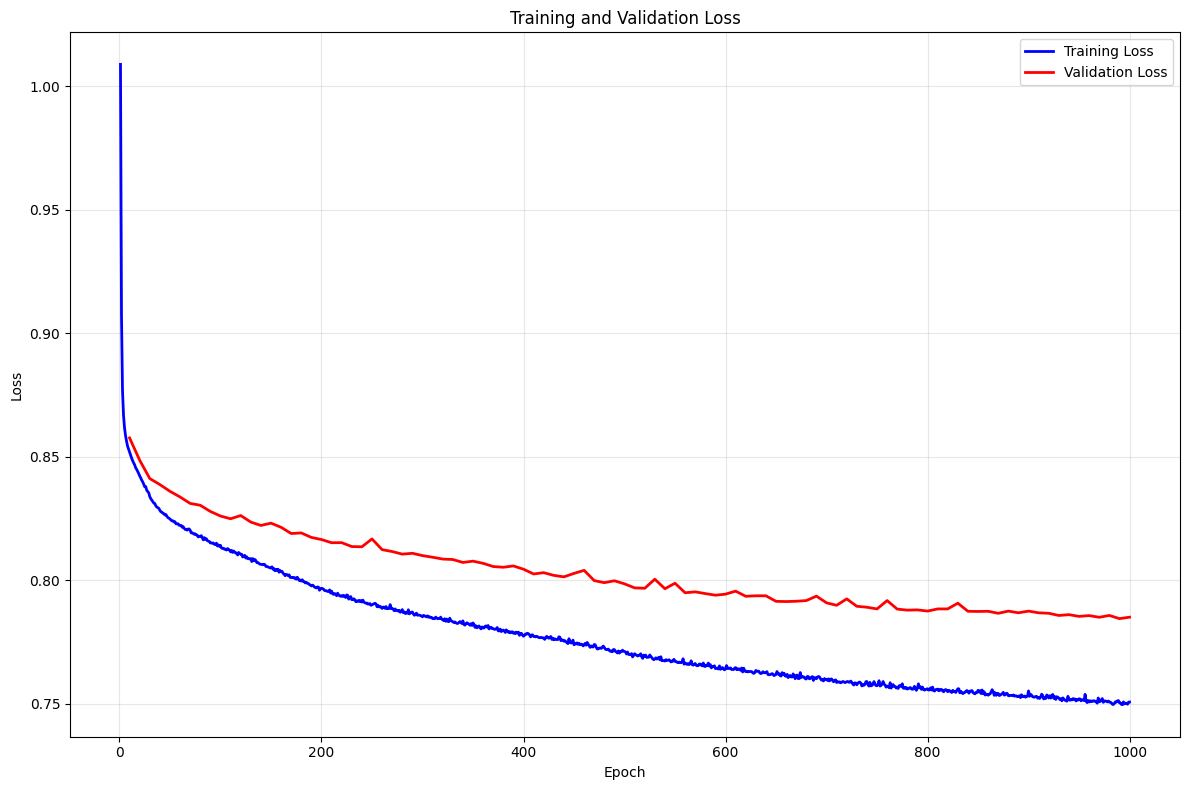

ROC curve saved to /w/halld-scshelf2101/lng/WORK/gluex_workshops/tutorial_ai_ml_2025/model_python/outputs/roc_curve.png


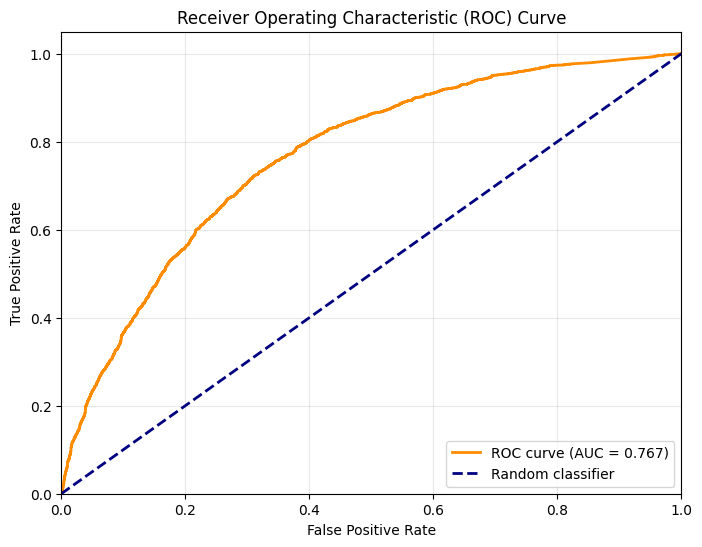

Predictions distribution plot saved to /w/halld-scshelf2101/lng/WORK/gluex_workshops/tutorial_ai_ml_2025/model_python/outputs/predictions_distribution.png


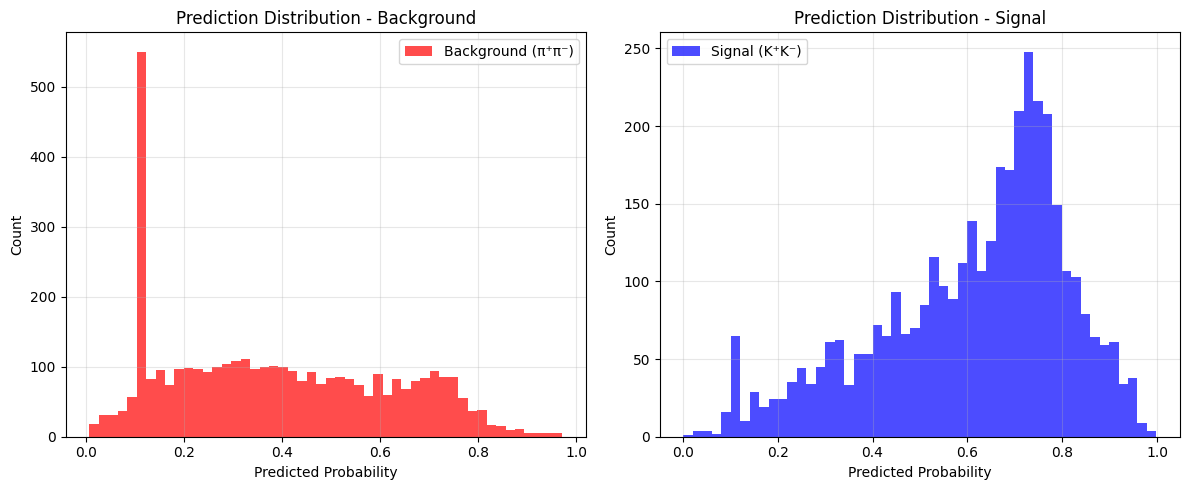

Saved predictions to /w/halld-scshelf2101/lng/WORK/gluex_workshops/tutorial_ai_ml_2025/model_python/outputs/predictions.pkl
Training completed!

To view the interactive dashboard, run with --dashboard flag


In [14]:
print("Starting hyperparameter optimization with Optuna...")
print(f"Study: {STUDY_NAME}")

# Run optimization
study = optimize_hyperparameters(n_trials=OPTUNA_N_TRIALS)

# Print optimization results
print(f"\nOptimization completed!")
print(f"Number of trials: {len(study.trials)}")
print(f"Complete trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])}")

# Train best model
print("\nTraining best model...")
train_best_model(study, X, y, X_test, y_test, scaler)

print("Training completed!")
print(f"\nTo view the interactive dashboard, run with --dashboard flag")

# Dashboard

Optuna provides a useful dashboard to visualize the optimization results including:
- **Pareto front**: comparing multi-objective results
- **Trial details**: viewing the hyperparameters and results of each trial
- **Parallel coordinate plot**: viewing the relationships between hyperparameters
- **Contour plots**: showing correlation between (hyperparameter 1, hyperparameter 2, Objective)

Example screenshot 1:

<img src="images/optuna-dash-1.png" width='1600'>

Example screenshot 2:

<img src="images/optuna-dash-2.png" width='1600'>

In [ ]:
print(f"You can start the dashboard by running in a terminal (in the same directory as this file):")
print(f"python launch_optuna_dash.py {OPTUNA_DB_URL}")
print(f"\nNote: Objective 0 = AUC, Objective 1 = Accuracy")

You can start the dashboard by running in a terminal:
python launch_optuna_dash.py sqlite:////w/halld-scshelf2101/lng/WORK/gluex_workshops/tutorial_ai_ml_2025/model_python/outputs/optuna_studies.db

Note: Objective 0 = AUC, Objective 1 = Accuracy
